In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")


In [18]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [19]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [22]:
for i in ["Hours Studied","Sleep Hours","Sample Question Papers Practiced"]:
    print(i,":",df[i].unique())
    print("."*60)

Hours Studied : [7 4 8 5 3 6 2 1 9]
............................................................
Sleep Hours : [9 4 7 5 8 6]
............................................................
Sample Question Papers Practiced : [1 2 5 6 0 8 3 4 9 7]
............................................................


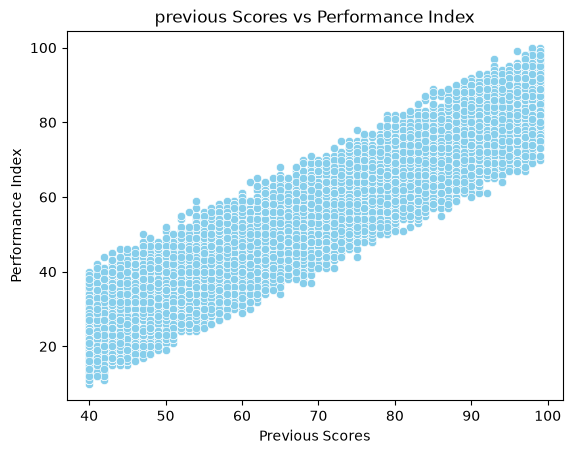

In [24]:
sns.scatterplot(x="Previous Scores",y="Performance Index",color="skyblue",data=df)
plt.title("previous Scores vs Performance Index")
plt.show()

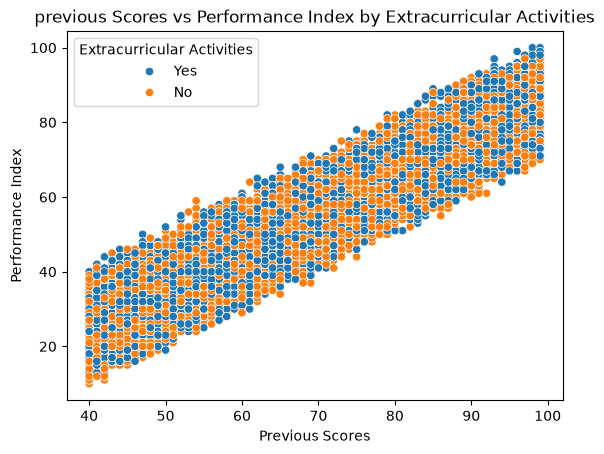

In [25]:
sns.scatterplot(x="Previous Scores",y="Performance Index",hue="Extracurricular Activities", color="skyblue",data=df)
plt.title("previous Scores vs Performance Index by Extracurricular Activities")
plt.show()

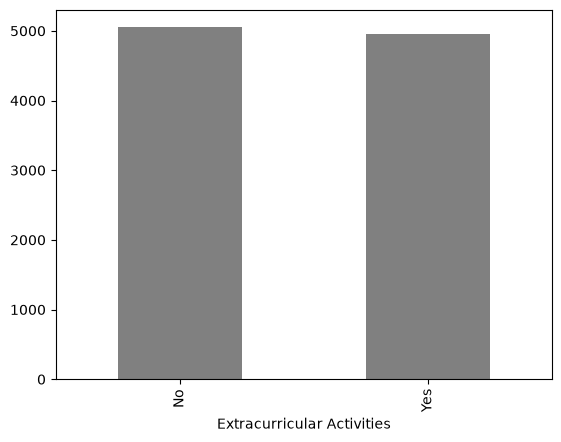

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64


In [32]:
df["Extracurricular Activities"].value_counts().plot(kind="bar", color="grey")
plt.show()

print(df["Extracurricular Activities"].value_counts())

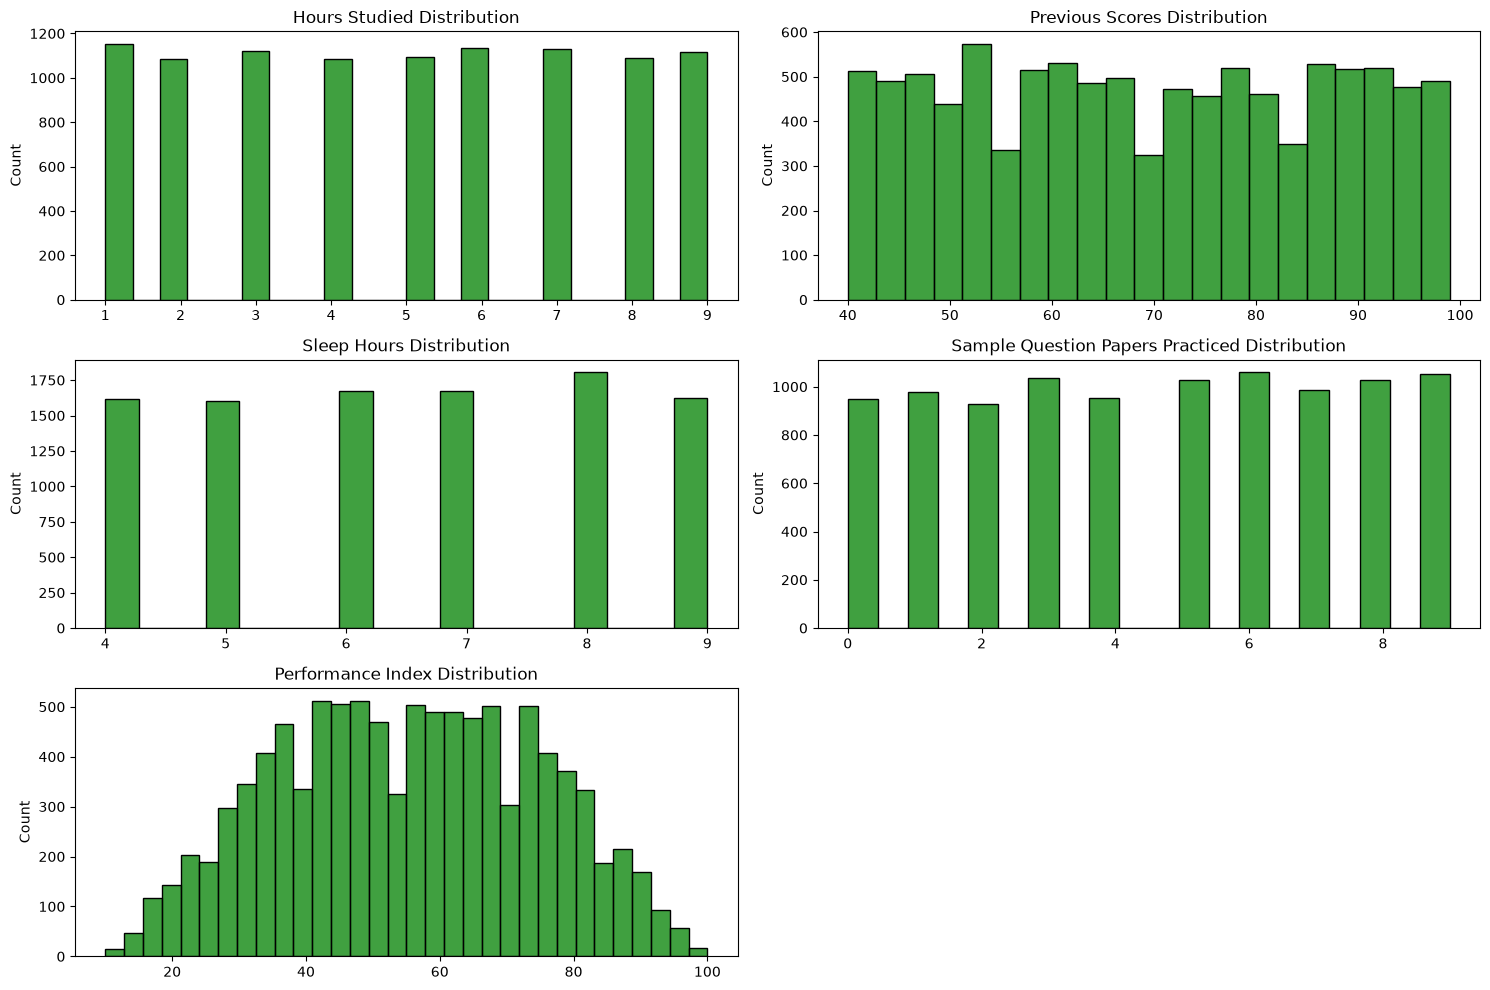

In [38]:
plt.figure(figsize=(15,10))

for i, col in enumerate([
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced","Performance Index"
]):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[col], color="green")
    plt.title(f"{col} Distribution")
    plt.xlabel("")

plt.tight_layout()
plt.show()

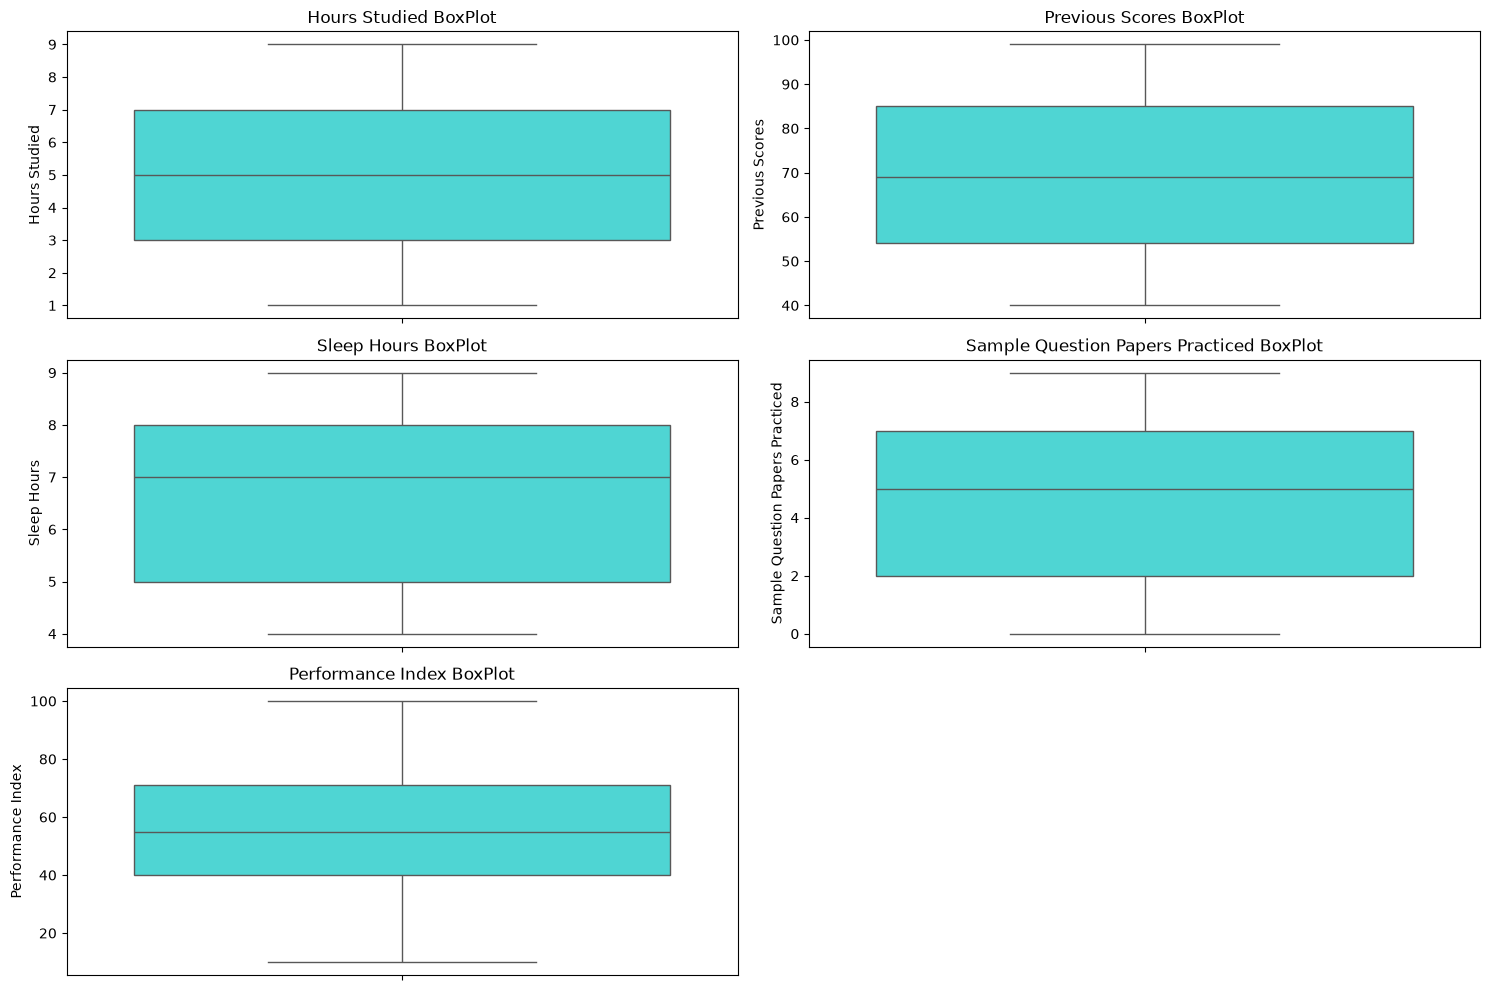

In [42]:
plt.figure(figsize=(15,10))
for i, col in enumerate([
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced","Performance Index"
]):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(df[col], color="#39EBE9")
    plt.title(f"{col} BoxPlot")
    plt.xlabel("")

plt.tight_layout()
plt.show()

In [45]:
from sklearn.model_selection import train_test_split

x = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

In [46]:
print(f"X train shape: {x_train.shape}")
print(f"X test shape: {x_test.shape}")
print(f"Y train shape: {y_train.shape}")
print(f"Y test shape: {y_test.shape}")

X train shape: (7500, 5)
X test shape: (2500, 5)
Y train shape: (7500,)
Y test shape: (2500,)


In [47]:
x_train["Extracurricular Activities"] = x_train["Extracurricular Activities"].map({"Yes":1,"No":0})
x_test["Extracurricular Activities"] = x_test["Extracurricular Activities"].map({"Yes":1,"No":0})

print(x_train["Extracurricular Activities"].unique())
print(x_test["Extracurricular Activities"].unique())

[0 1]
[0 1]


In [49]:
x_train.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
4901,5,49,0,5,5
4375,7,88,1,4,9
6698,3,94,1,7,1
9805,9,54,1,5,9
1101,4,56,1,8,6


In [50]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

In [53]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

In [56]:
for i in range(len(list(models))):

    model = list(models.values())[i]

    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(
        y_train, y_train_pred
    )

    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(
        y_test, y_test_pred
    )

    print(list(models.keys())[i])

    print("RMSE :", model_test_rmse)
    print("Mean Absolute Error :", model_test_mae)
    print("R2 Score :", model_test_r2)

    print("-" * 40)

Linear Regression
RMSE : 2.008119571992444
Mean Absolute Error : 1.5975792091646108
R2 Score : 0.9890550757439104
----------------------------------------
Ridge
RMSE : 2.0081238202509857
Mean Absolute Error : 1.5975800205432158
R2 Score : 0.9890550294349975
----------------------------------------
Lasso
RMSE : 2.1954630374044095
Mean Absolute Error : 1.735894295901938
R2 Score : 0.9869176464437092
----------------------------------------
ElasticNet
RMSE : 2.1911455426928965
Mean Absolute Error : 1.7293004357445956
R2 Score : 0.9869690501366244
----------------------------------------
KNN
RMSE : 2.4317006394702454
Mean Absolute Error : 1.9412
R2 Score : 0.9839507833228293
----------------------------------------
Decision Tree
RMSE : 2.9667284637758438
Mean Absolute Error : 2.3420666666666663
R2 Score : 0.9761114813692323
----------------------------------------
Random Forest
RMSE : 2.267685028222984
Mean Absolute Error : 1.81081976984127
R2 Score : 0.9860427747344089
-------------------

In [57]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.85,1.02,0.58,0.48,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.87
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [64]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
    "Yes": 1,
    "No": 0
})

In [65]:
print(df["Extracurricular Activities"].unique())

[1 0]


In [67]:
x = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

In [70]:
print(df.dtypes)

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities            int64
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object


In [71]:
# Features and target
x = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

In [72]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

In [73]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.85,1.02,0.58,0.48,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.87
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [74]:
from sklearn.metrics import r2_score

y_pred = model.predict(x_test)
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9890550757439104


In [75]:
print(x_train.head())

      Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
4901              5               49                           0            5   
4375              7               88                           1            4   
6698              3               94                           1            7   
9805              9               54                           1            5   
1101              4               56                           1            8   

      Sample Question Papers Practiced  
4901                                 5  
4375                                 9  
6698                                 1  
9805                                 9  
1101                                 6  


In [76]:
sample = [[7, 85, 1, 7, 5]]

prediction = model.predict(sample)

print("Predicted Performance Index:", prediction[0])

Predicted Performance Index: 77.38338404447933


In [77]:
import joblib

joblib.dump(model, "student_performance_model.pkl")
print("Model saved successfully!")

Model saved successfully!
